In [5]:
#%pip install pandas
import pandas as pd

In [6]:
inventory = pd.read_csv("../data/processed/drop_cases_inventory.csv")
price_history = pd.read_csv("../data/processed/drop_cases_prices.csv")

In [7]:
inventory.info()
inventory.head()

<class 'pandas.DataFrame'>
RangeIndex: 13 entries, 0 to 12
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   case_name  13 non-null     str  
 1   quantity   13 non-null     int64
dtypes: int64(1), str(1)
memory usage: 340.0 bytes


,case_name,quantity
0,Dream & Nightmares,16
1,Fever,35
2,Fracture,9
3,Gallery,6
4,Horizon,1


In [8]:
price_history.info()
price_history.head()

<class 'pandas.DataFrame'>
RangeIndex: 146 entries, 0 to 145
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   date        146 non-null    str    
 1   case_name   146 non-null    str    
 2   unit_price  146 non-null    float64
dtypes: float64(1), str(2)
memory usage: 3.6 KB


,date,case_name,unit_price
0,2025-09-17,Dream & Nightmares,1.65
1,2025-10-27,Dream & Nightmares,1.84
2,2025-11-22,Dream & Nightmares,1.66
3,2025-12-03,Dream & Nightmares,1.52
4,2025-12-18,Dream & Nightmares,1.46


In [9]:
price_history_with_inventory = price_history.merge(
    inventory,
    on="case_name",
    how="left"
)

price_history_with_inventory.head()

,date,case_name,unit_price,quantity
0,2025-09-17,Dream & Nightmares,1.65,16
1,2025-10-27,Dream & Nightmares,1.84,16
2,2025-11-22,Dream & Nightmares,1.66,16
3,2025-12-03,Dream & Nightmares,1.52,16
4,2025-12-18,Dream & Nightmares,1.46,16


In [10]:
price_history_with_inventory["total_value"] = (
    price_history_with_inventory["unit_price"]
    * price_history_with_inventory["quantity"]
)

price_history_with_inventory

,date,case_name,unit_price,quantity,total_value
0,2025-09-17,Dream & Nightmares,1.65,16,26.40
1,2025-10-27,Dream & Nightmares,1.84,16,29.44
2,2025-11-22,Dream & Nightmares,1.66,16,26.56
3,2025-12-03,Dream & Nightmares,1.52,16,24.32
4,2025-12-18,Dream & Nightmares,1.46,16,23.36
...,...,...,...,...,...
141,2026-03-31,Snakebite,0.76,7,5.32
142,2026-05-05,Snakebite,0.85,7,5.95
143,2026-06-11,Snakebite,0.74,7,5.18
144,2026-07-01,Snakebite,0.66,7,4.62


In [11]:
price_history["date"] = pd.to_datetime(price_history["date"])
price_history = price_history.sort_values("date")

In [12]:
dream = price_history[
    price_history["case_name"] == "Dream & Nightmares"
].copy()

dream

,date,case_name,unit_price
0,2025-09-17,Dream & Nightmares,1.65
1,2025-10-27,Dream & Nightmares,1.84
2,2025-11-22,Dream & Nightmares,1.66
3,2025-12-03,Dream & Nightmares,1.52
4,2025-12-18,Dream & Nightmares,1.46
5,2026-01-14,Dream & Nightmares,1.41
6,2026-02-13,Dream & Nightmares,1.45
7,2026-03-03,Dream & Nightmares,1.55
8,2026-03-13,Dream & Nightmares,1.68
9,2026-03-31,Dream & Nightmares,1.88


In [13]:
#%pip install matplotlib.pyplot
#%pip install seaborn
#%pip install plotly
#%pip install ipykernel
#%pip install --upgrade nbformat

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [15]:
dream["performance"] = (
    dream["unit_price"] / dream["unit_price"].iloc[0]
) * 100

In [16]:
dream["performance"] = (
    dream["unit_price"] / dream["unit_price"].iloc[0] - 1
) * 100
dream[["date", "unit_price", "performance"]]

,date,unit_price,performance
0,2025-09-17,1.65,0.000000
1,2025-10-27,1.84,11.515152
2,2025-11-22,1.66,0.606061
3,2025-12-03,1.52,-7.878788
4,2025-12-18,1.46,-11.515152
5,2026-01-14,1.41,-14.545455
6,2026-02-13,1.45,-12.121212
7,2026-03-03,1.55,-6.060606
8,2026-03-13,1.68,1.818182
9,2026-03-31,1.88,13.939394


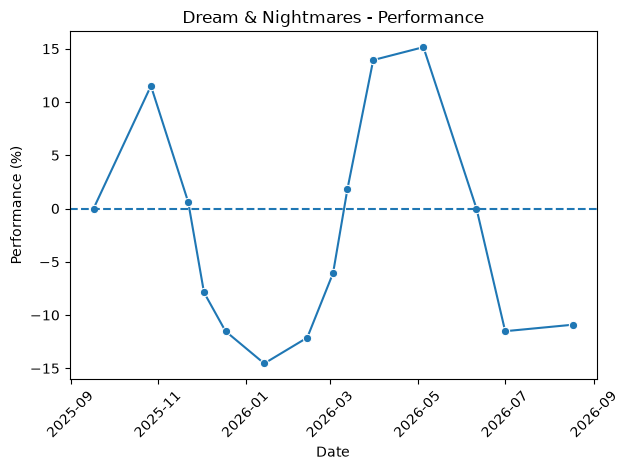

In [17]:
sns.lineplot(
    data=dream,
    x="date",
    y="performance",
    marker="o"
)

plt.axhline(0, linestyle="--")

plt.title("Dream & Nightmares - Performance")
plt.xlabel("Date")
plt.ylabel("Performance (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [18]:
price_history["performance"] = (
    price_history["unit_price"]
    / price_history.groupby("case_name")["unit_price"].transform("first")
    - 1
) * 100

price_history.head(20)

,date,case_name,unit_price,performance
0,2025-09-17,Dream & Nightmares,1.65,0.000000
42,2025-09-17,Gallery,1.43,0.000000
14,2025-09-17,Fever,0.92,0.000000
93,2025-09-17,Recoil,0.34,0.000000
61,2025-09-17,Kilowatt,0.43,0.000000
28,2025-09-17,Fracture,0.62,0.000000
107,2025-09-17,Revolution,0.47,0.000000
1,2025-10-27,Dream & Nightmares,1.84,11.515152
43,2025-10-27,Gallery,1.21,-15.384615
29,2025-10-27,Fracture,0.60,-3.225806


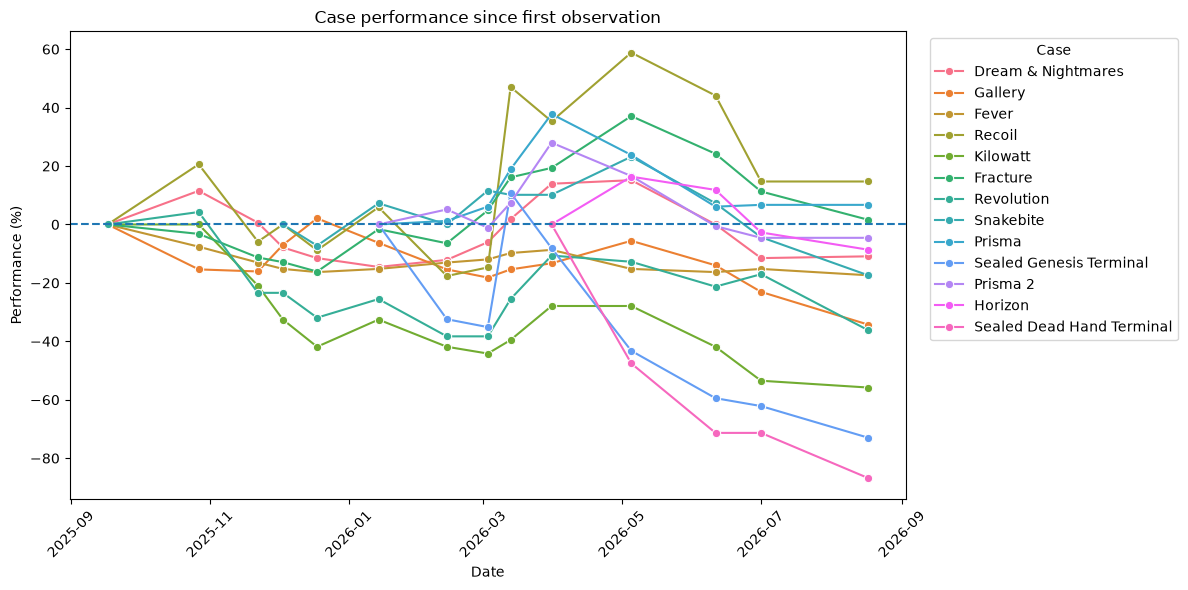

In [19]:
plt.figure(figsize=(12, 6))

sns.lineplot(
    data=price_history,
    x="date",
    y="performance",
    hue="case_name",
    marker="o"
)

plt.axhline(0, linestyle="--")

plt.title("Case performance since first observation")
plt.xlabel("Date")
plt.ylabel("Performance (%)")
plt.xticks(rotation=45)
plt.legend(
    title="Case",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

In [24]:
fig = px.line(
    price_history,
    x="date",
    y="performance",
    color="case_name",
    markers=True,
    title="Case performance since first observation"
)
fig.show()
